# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Número de compras feitas pelo site da empresa.**

# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

In [77]:
import pandas as pd
df = pd.read_csv('/content/marketing_campaign.csv', delimiter=';')
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


# Exploração e Limpeza

In [78]:
# Padronizando as letras do dataset

df.columns = df.columns.str.lower()

In [79]:
# Estatística básicas

df.describe()

,year_birth,income,kidhome,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numstorepurchases,numwebvisitsmonth,complain,webpurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


In [80]:
# Análise Geral
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year_birth         2240 non-null   int64  
 1   education          2240 non-null   object 
 2   marital_status     2240 non-null   object 
 3   income             2216 non-null   float64
 4   kidhome            2240 non-null   int64  
 5   recency            2240 non-null   int64  
 6   mntwines           2240 non-null   int64  
 7   mntfruits          2240 non-null   int64  
 8   mntmeatproducts    2240 non-null   int64  
 9   mntfishproducts    2240 non-null   int64  
 10  mntsweetproducts   2240 non-null   int64  
 11  mntgoldprods       2240 non-null   int64  
 12  numstorepurchases  2240 non-null   int64  
 13  numwebvisitsmonth  2240 non-null   int64  
 14  complain           2240 non-null   int64  
 15  webpurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

In [81]:
# Valores nulos
df.isnull().sum()

,0
year_birth,0
education,0
marital_status,0
income,24
kidhome,0
recency,0
mntwines,0
mntfruits,0
mntmeatproducts,0
mntfishproducts,0


In [82]:
# Preencher com mediana

df["income"] = df["income"].fillna(df["income"].median())

In [83]:
# Criar Variável Idade


df["age"] = 2024 - df["year_birth"]


In [84]:
# Converter Variáveis Categóricas

df = pd.get_dummies(
    df,
    columns=["education", "marital_status"],
    drop_first=True
)

# Análise

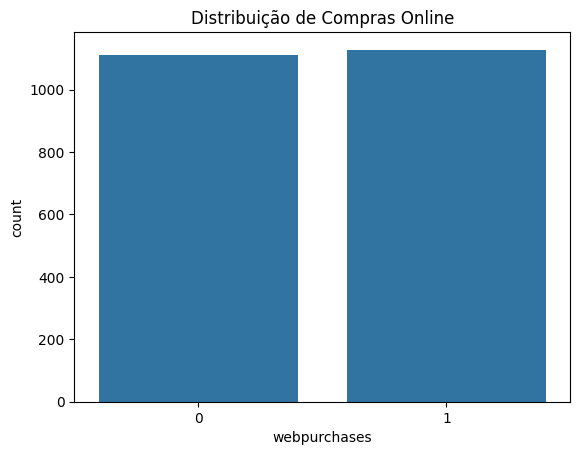

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Distribuição da variável alvo

sns.countplot(
    x="webpurchases",
    data=df
)

plt.title("Distribuição de Compras Online")
plt.show()

# INSIGTHS

- A variável webpurchases apresenta distribuição equilibrada entre clientes que compram (1) e que não compram (0). Isso indica ausência de desbalanceamento significativo nas classes. Esse cenário é favorável para o treinamento de modelos de classificação mais confiáveis.

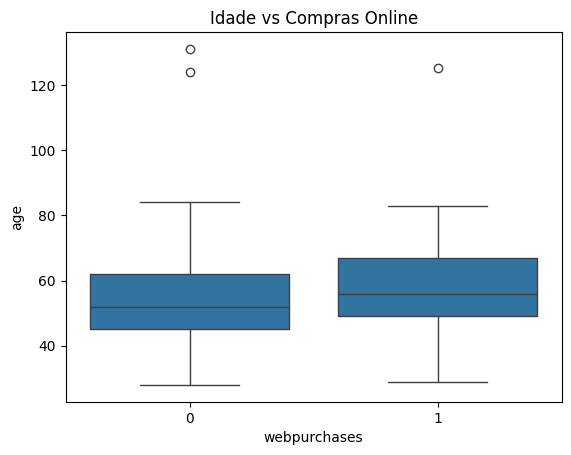

In [86]:
# Idade vs Compras Online

sns.boxplot(
    x="webpurchases",
    y="age",
    data=df
)

plt.title("Idade vs Compras Online")
plt.show()

In [87]:
df.age.describe()

,age
count,2240.000000
mean,55.194196
std,11.984069
min,28.000000
25%,47.000000
50%,54.000000
75%,65.000000
max,131.000000


In [88]:
# Remover Idades Irreais

df = df[df["age"] <= 100]

# Retirar a Coluna year_birth

df.drop("year_birth", axis=1, inplace=True)

#INSIGHTS

- Clientes que realizam compras online tendem a apresentar uma idade mediana ligeiramente maior. A diferença entre os grupos não é muito acentuada, indicando influência moderada da idade. A variável pode ser útil para segmentação, mas não é um forte preditor isolado.

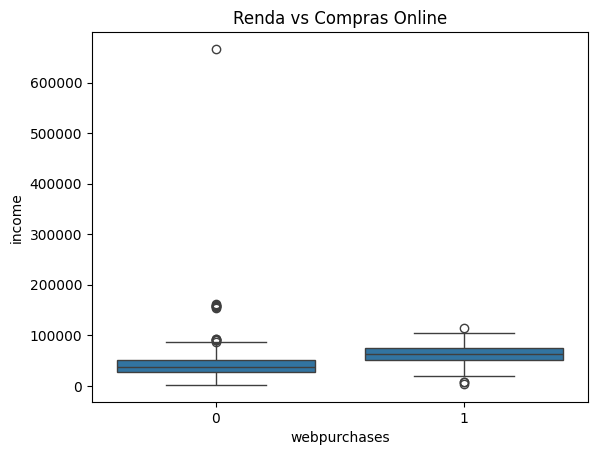

In [89]:
# Renda vs Compras Online

sns.boxplot(
    x="webpurchases",
    y="income",
    data=df
)

plt.title("Renda vs Compras Online")
plt.show()

# INSIGHTS

- Clientes que realizam compras online apresentam, em média, rendas mais altas. A presença de outliers indica alguns clientes com renda muito superior ao padrão. Isso sugere que o poder aquisitivo tem influência positiva no comportamento de compra online.

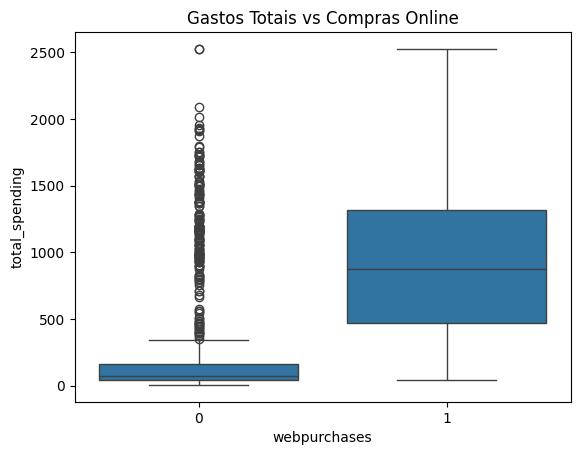

In [90]:
# Gastos por Categoria

# Somar gastos
df["total_spending"] = (
    df["mntwines"]
    + df["mntfruits"]
    + df["mntmeatproducts"]
    + df["mntfishproducts"]
    + df["mntsweetproducts"]
    + df["mntgoldprods"]
)
# Visualizar
sns.boxplot(
    x="webpurchases",
    y="total_spending",
    data=df
)

plt.title("Gastos Totais vs Compras Online")
plt.show()

# INSIGHTS

- Clientes que realizam compras online possuem valores de gastos totais significativamente maiores. A diferença entre compradores e não compradores é bem evidente. Isso indica que o histórico de gastos é um dos fatores mais importantes para prever compras online.

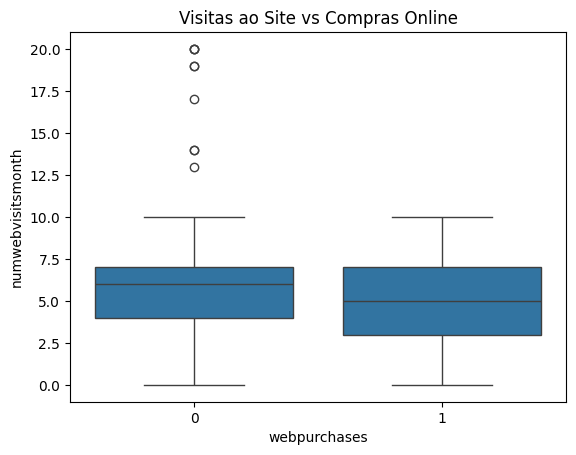

In [91]:
# Visitas ao Site vs Compras

sns.boxplot(
    x="webpurchases",
    y="numwebvisitsmonth",
    data=df
)

plt.title("Visitas ao Site vs Compras Online")
plt.show()

# INSGHTS

- Clientes que não compram tendem a apresentar maior variabilidade no número de visitas ao site. Isso pode indicar usuários que navegam frequentemente, mas não necessariamente convertem em compras. Esse grupo pode ser alvo estratégico para campanhas de marketing.

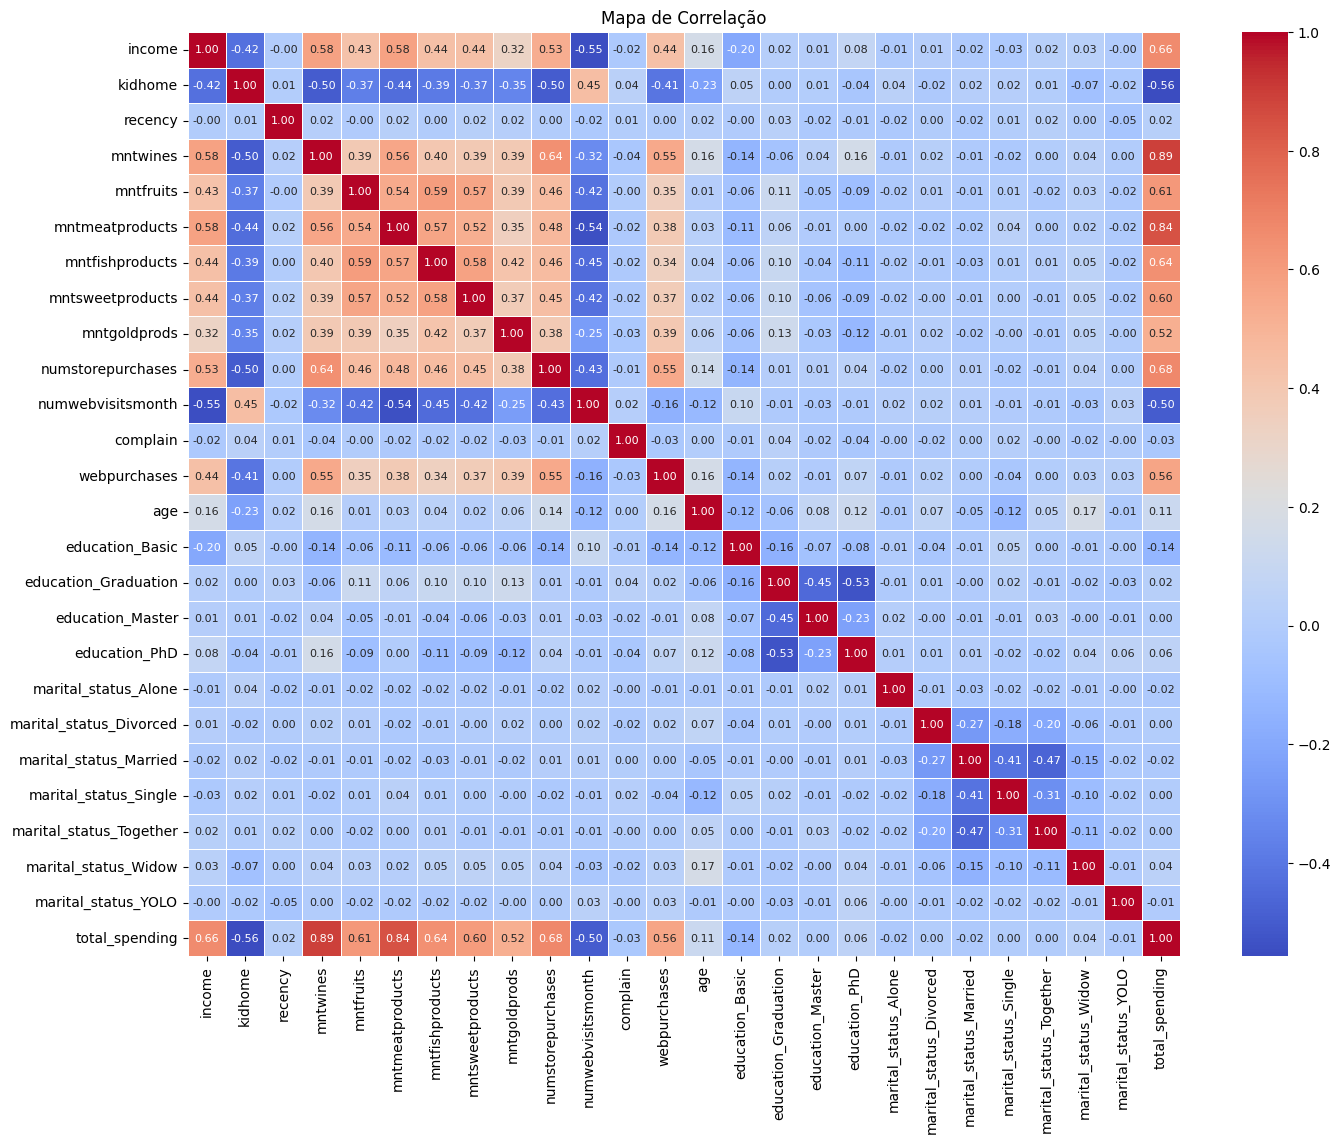

In [92]:
# Mapa de Correlação

plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Mapa de Correlação")

plt.show()

In [93]:
# Matriz de Correlação em forma de tabela

df.corr()

,income,kidhome,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numstorepurchases,...,education_Master,education_PhD,marital_status_Alone,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Together,marital_status_Widow,marital_status_YOLO,total_spending
income,1.000000,-0.424887,-0.003205,0.576731,0.428191,0.577524,0.437214,0.435918,0.321082,0.527346,...,0.011901,0.080112,-0.012351,0.009175,-0.016007,-0.025935,0.022264,0.031581,-0.004535,0.664707
kidhome,-0.424887,1.000000,0.007544,-0.496367,-0.372488,-0.437059,-0.387536,-0.370656,-0.349633,-0.500387,...,0.008029,-0.041325,0.037824,-0.020858,0.017201,0.020564,0.007061,-0.073854,-0.024691,-0.556902
recency,-0.003205,0.007544,1.000000,0.016668,-0.003592,0.023705,0.001532,0.023045,0.017412,0.001117,...,-0.023345,-0.010820,-0.023761,0.001971,-0.022657,0.008240,0.020957,0.000249,-0.047641,0.021199
mntwines,0.576731,-0.496367,0.016668,1.000000,0.388518,0.561993,0.399073,0.385992,0.386376,0.642433,...,0.038472,0.156010,-0.012995,0.022378,-0.010644,-0.023391,0.003611,0.036627,0.001601,0.891734
mntfruits,0.428191,-0.372488,-0.003592,0.388518,1.000000,0.542057,0.594438,0.567054,0.390042,0.463168,...,-0.051756,-0.085819,-0.020553,0.010674,-0.010698,0.008163,-0.016748,0.032431,-0.017531,0.613122
mntmeatproducts,0.577524,-0.437059,0.023705,0.561993,0.542057,1.000000,0.567880,0.523418,0.348845,0.480110,...,-0.006982,0.002040,-0.022835,-0.024208,-0.021923,0.036003,0.001326,0.018720,-0.015502,0.842655
mntfishproducts,0.437214,-0.387536,0.001532,0.399073,0.594438,0.567880,1.000000,0.579553,0.422103,0.460099,...,-0.044193,-0.105502,-0.020028,-0.014651,-0.031108,0.007251,0.014670,0.047926,-0.018357,0.642395
mntsweetproducts,0.435918,-0.370656,0.023045,0.385992,0.567054,0.523418,0.579553,1.000000,0.369193,0.448801,...,-0.063546,-0.088405,-0.017814,-0.001242,-0.007060,0.003168,-0.014483,0.054624,-0.017440,0.602701
mntgoldprods,0.321082,-0.349633,0.017412,0.386376,0.390042,0.348845,0.422103,0.369193,1.000000,0.383264,...,-0.030550,-0.121856,-0.011948,0.015729,-0.017465,-0.001529,-0.014608,0.046429,-0.001132,0.522762
numstorepurchases,0.527346,-0.500387,0.001117,0.642433,0.463168,0.480110,0.460099,0.448801,0.383264,1.000000,...,0.014098,0.043968,-0.020231,0.004294,0.013748,-0.023638,-0.010029,0.036087,0.001893,0.675573


# INSIGHTS

- A matriz de correlação mostrou que total_spending (≈ 0.56) e income (≈ 0.44) possuem correlação positiva relevante com webpurchases, indicando forte influência financeira no comportamento de compra. A variável kidhome (≈ -0.41) apresentou correlação negativa, sugerindo que clientes com crianças tendem a comprar menos online. Além disso, diferentes categorias de gastos apresentaram forte associação com o total gasto, indicando consistência no padrão de consumo.

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








In [94]:
# Correlação com a variável alvo
corr_web = df.corr()[["webpurchases"]].sort_values(
    by="webpurchases",
    ascending=False
)

corr_web.round(2)

,webpurchases
webpurchases,1.00
total_spending,0.56
mntwines,0.55
numstorepurchases,0.55
income,0.44
mntgoldprods,0.39
mntmeatproducts,0.38
mntsweetproducts,0.37
mntfruits,0.35
mntfishproducts,0.34


In [95]:
# Ver correlação baixa

corr_web[abs(corr_web["webpurchases"]) < 0.05]

,webpurchases
marital_status_Widow,0.030443
marital_status_YOLO,0.029688
marital_status_Divorced,0.022395
education_Graduation,0.021848
marital_status_Together,0.004695
marital_status_Married,0.001317
recency,0.000899
education_Master,-0.008196
marital_status_Alone,-0.012494
complain,-0.029217


In [96]:
# Separação y e X

# Variável alvo
y = df["webpurchases"]

# Variáveis independentes
X = df.drop("webpurchases", axis=1)

In [97]:
from sklearn.model_selection import train_test_split

# Separar Treino e Teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.preprocessing import StandardScaler

# Padronização dos Dados

scaler = StandardScaler()

# Ajusta no treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica no teste
X_test_scaled = scaler.transform(X_test)

# Verificar resultado
X_train_scaled[:5]

array([[-0.82615354, -0.83624762,  1.6466329 , -0.79950076, -0.66418137,
        -0.67916905, -0.65622741, -0.66052721, -0.80574058, -0.85784361,
         1.09107794, -0.10479462, -0.7042779 , -0.15775106,  0.98793224,
        -0.44223199, -0.52782078, -0.03577136, -0.33274137,  1.24620141,
        -0.52979939, -0.58694269, -0.17788029, -0.02528609, -0.92447191],
       [-0.93577398, -0.83624762,  0.27511435, -0.79357671, -0.36444988,
        -0.63512965, -0.54678236, -0.40082102,  0.13655804, -0.85784361,
         0.68247852, -0.10479462,  1.52914644, -0.15775106, -1.01221517,
         2.26125656, -0.52782078, -0.03577136, -0.33274137,  1.24620141,
        -0.52979939, -0.58694269, -0.17788029, -0.02528609, -0.77355349],
       [-1.16027424,  1.03069607, -1.67929958, -0.88539949, -0.26453938,
        -0.63072571, -0.49205983, -0.66052721, -0.20266947, -1.16442622,
         0.68247852, -0.10479462, -1.73508913, -0.15775106,  0.98793224,
        -0.44223199, -0.52782078, -0.03577136, -0

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [99]:
# Importar Modelos

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Modelo 1 Regressão Logística



In [100]:
# Criar modelo
log_model = LogisticRegression(max_iter=1000)

# Treinar
log_model.fit(X_train_scaled, y_train)

# Prever
y_pred_log = log_model.predict(X_test_scaled)

# Modelo 2 Random Forest


In [101]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Treinar
rf_model.fit(X_train, y_train)

# Prever
y_pred_rf = rf_model.predict(X_test)

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

In [102]:
print("=== Regressão Logística ===")

print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1-score:",
      f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_log
))

=== Regressão Logística ===
Accuracy: 0.8497023809523809
Precision: 0.8672839506172839
Recall: 0.8289085545722714
F1-score: 0.8476621417797888

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       333
           1       0.87      0.83      0.85       339

    accuracy                           0.85       672
   macro avg       0.85      0.85      0.85       672
weighted avg       0.85      0.85      0.85       672



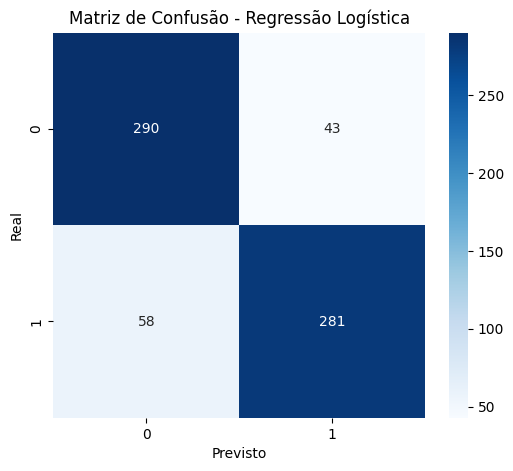

In [105]:
from sklearn.metrics import confusion_matrix

# Matriz de confusão - Regressão Logística
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

In [103]:
print("=== Random Forest ===")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1-score:",
      f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf
))

=== Random Forest ===
Accuracy: 0.9196428571428571
Precision: 0.8969359331476323
Recall: 0.9498525073746312
F1-score: 0.9226361031518625

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       333
           1       0.90      0.95      0.92       339

    accuracy                           0.92       672
   macro avg       0.92      0.92      0.92       672
weighted avg       0.92      0.92      0.92       672



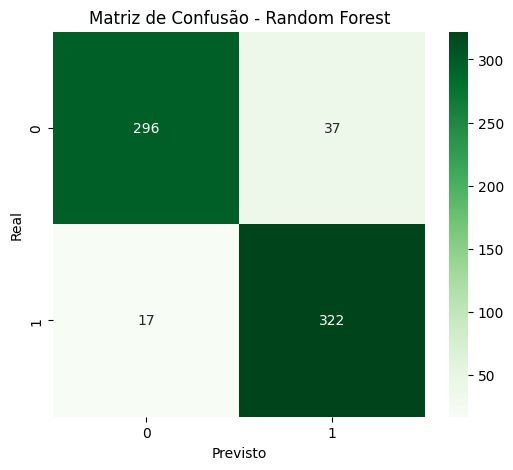

In [106]:
# Matriz de confusão - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

# Comparação dos Modelos

- O modelo de Regressão Logística apresentou desempenho satisfatório, com accuracy de 84,97%, demonstrando boa capacidade de classificação geral. As métricas de precision (0.867), recall (0.829) e F1-score (0.848) indicam que o modelo foi capaz de identificar corretamente a maioria dos clientes compradores, embora ainda apresente alguns erros de classificação observados na matriz de confusão.

- O modelo Random Forest apresentou desempenho superior em todas as métricas avaliadas, atingindo accuracy de 91,96%, além de precision (0.897), recall (0.950) e F1-score (0.923). A matriz de confusão demonstrou menor quantidade de erros quando comparada ao modelo anterior, evidenciando maior robustez e capacidade preditiva.


---


Dessa forma, com base nas métricas de avaliação e na análise das matrizes de confusão, o modelo Random Forest foi identificado como o mais eficiente para esta base de dados, sendo o mais indicado para utilização em aplicações práticas de previsão de comportamento de compras online.